# Matplotlib Figures and Axes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 50)
y = np.sin(x)

```{contents}
:local:
:depth: 2
```


## Object-Oriented Plotting with `plt.subplots()`


::: {note}
But what's the difference between a **figure** and an **axes**?

| | **Figure** | **Axes** |
|---|---|---|
| Analogy | The full canvas/window | One plot region on that canvas |
| What it is | The top-level container | The area where data is drawn |
| Contains | One or more Axes | X/Y axis, ticks, lines, labels, title, legend |
| Commonly created by | `plt.figure()` or `plt.subplots()` | returned by `plt.subplots()` or added to a figure |

A good mental model is:

```text
Figure
└── Axes (a.k.a. one plot)
    ├── XAxis
    ├── YAxis
    ├── Title
    ├── Lines / Bars / etc.
    └── Legend
```
:::



Here we will learn two OO workflows:

- `plt.subplots()` for the standard, everyday workflow
- `plt.figure()` + `fig.add_axes()` for manual placement and inset-style layouts



### `plt.subplots()`

`plt.subplots()` creates the **figure** and **axes** objects in one step and returns them as a tuple.

- If you create a single subplot, you typically get one `Axes` object.
- If you create multiple subplots, you get a NumPy array of `Axes` objects.

Typical syntax:

`fig, ax = plt.subplots()`

The example below shows the standard one-axes case.


Text(0.5, 1.0, 'Title via Object-Oriented API')

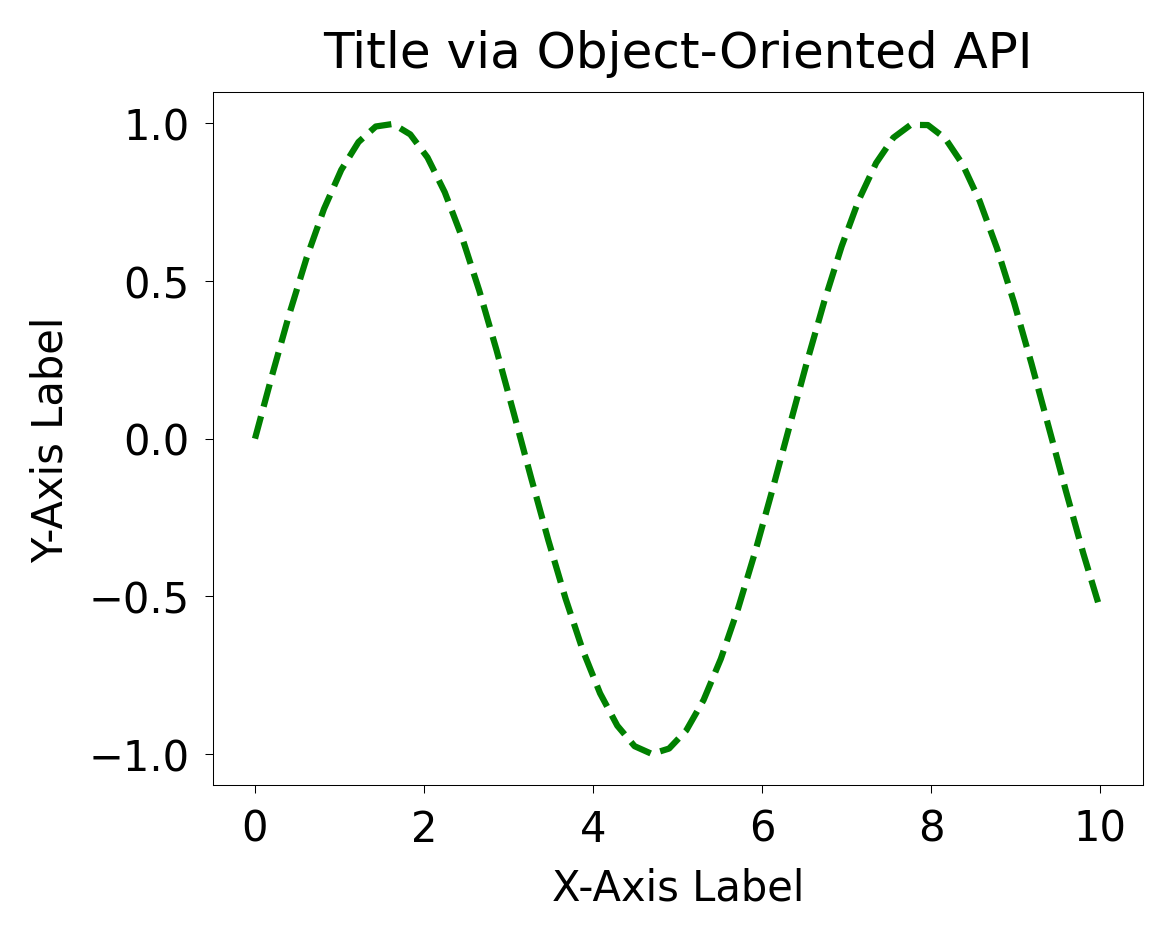

In [54]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

# fig, ax = plt.subplots()              ### single Axes case
# fig, axes = plt.subplots(1, 2)        ### multiple Axes case

fig, ax = plt.subplots(figsize=(4,3))   ### unpacking in one step
ax.plot(x, y, 'g--')                    ### plot on that axes

### common axes methods
ax.set_xlabel('X-Axis Label')
ax.set_ylabel('Y-Axis Label')
ax.set_title('Title via Object-Oriented API')


With `subplots()`, you can specify the number of rows and columns using the `nrows=` and `ncols=` parameters when creating the subplots() object. The example below creates an empty canvas of 1-row by 2-cols subplots. 

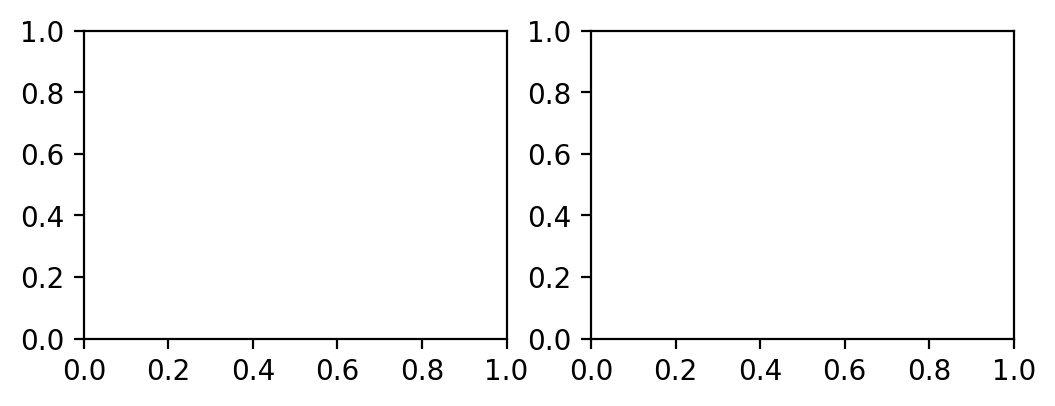

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)
# fig, axes = plt.subplots(1, 2)            ### same as above

In this example above, `axes` is an array variable containing two `Axes` objects. Looping over that array is a common pattern when you want to apply the same formatting to each subplot.

In [16]:
print(axes)

[<Axes: > <Axes: >]


Now we have access over the two Axes individually using **indexing** (`[0] and [1]`). We may plot them separately.

Text(0.5, 1.0, 'Second Plot')

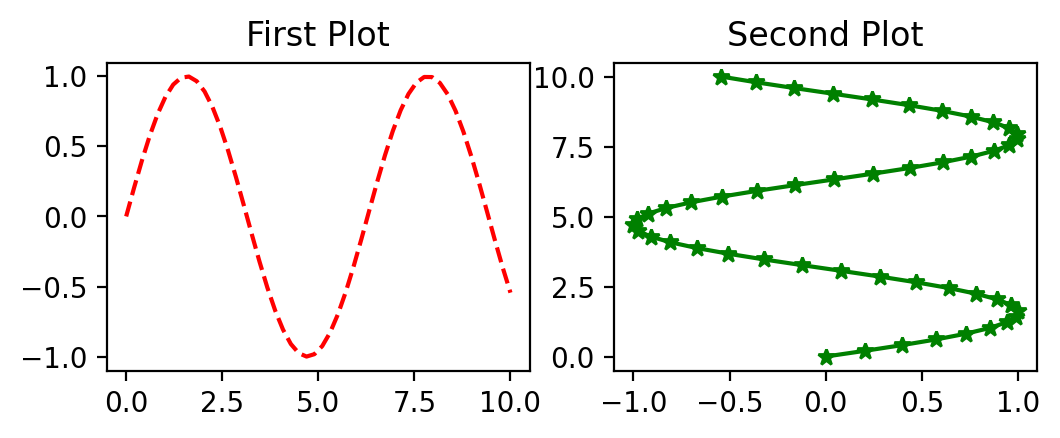

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

axes[0].plot(x, y, 'r--')    ### plot on the first axes
axes[0].set_title('First Plot')  ### set title for the first axes   

axes[1].plot(y, x, 'g*-')    ### plot on the second axes
axes[1].set_title('Second Plot')  ### set title for the second axes

# plt.show()

It's not uncommon to loop through the Axes object then fine tune the plots.

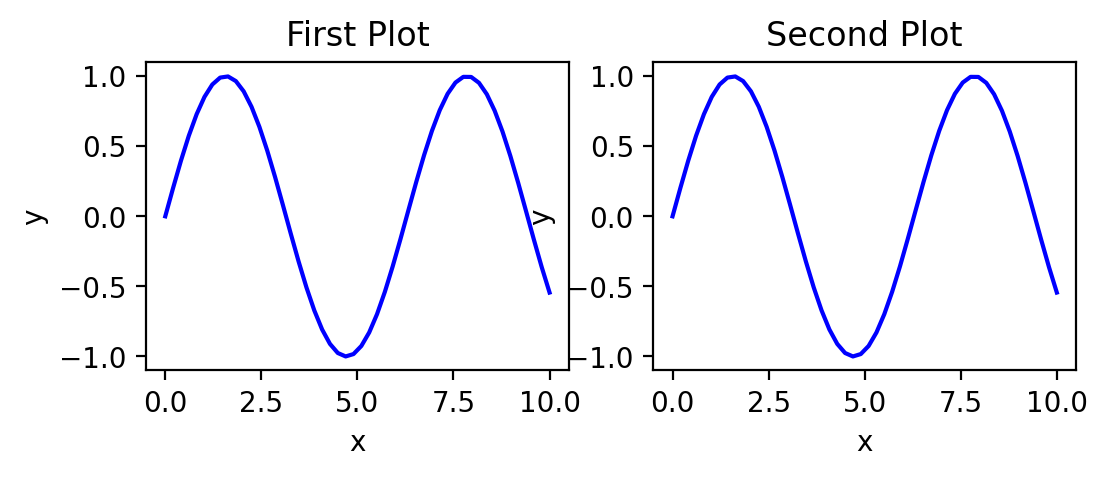

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

for ax in axes:
    ax.plot(x, y, 'b')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

axes[0].set_title('First Plot')  ### set title for the first axes
axes[1].set_title('Second Plot')  ### set title for the second axes
### display the figure object    
# fig                             ### to show the figure in some environments
plt.show()


A common issue in Matplotlib is overlapping subplot labels or titles. `plt.tight_layout()` can automatically adjust spacing so the figure is easier to read. (compare with the plots above)


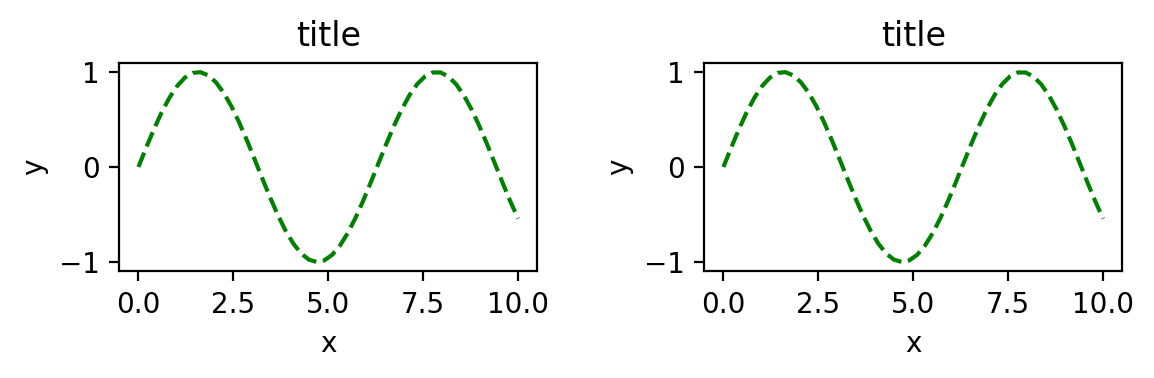

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)

for ax in axes:
    ax.plot(x, y, 'g--')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

fig    
plt.tight_layout()

In [20]:
### Exercise: Side-by-Side Subplots with plt.subplots()
#   1. Use plt.subplots(1, 2, figsize=(8, 3)) to create a figure and two axes.
#   2. On axes[0], plot x vs np.sin(x) with 'b-', title "Sine",
#      x-label "x", and y-label "y".
#   3. On axes[1], plot x vs np.cos(x) with 'r--', title "Cosine",
#      x-label "x", and y-label "y".
#   4. Call plt.tight_layout() at the end.
#   (`x` and `np` are already available above.)
### Your code starts here.




### Your code ends here.

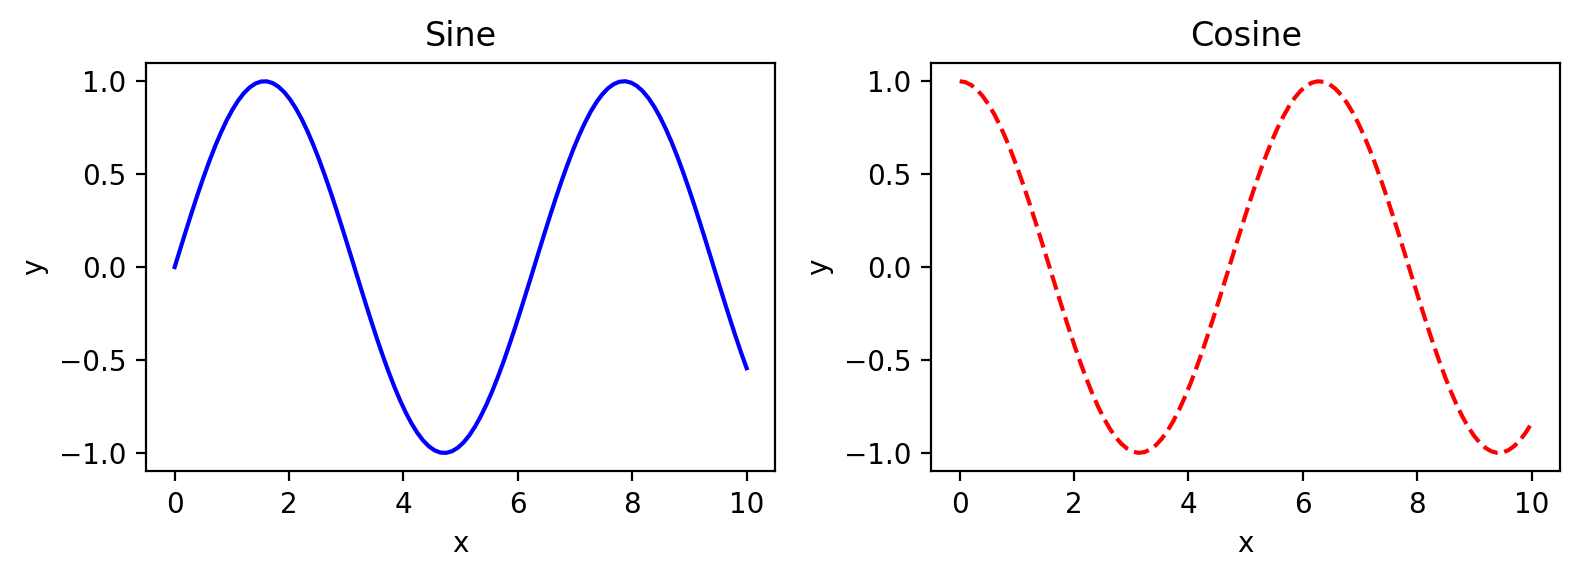

In [21]:
### Solution

x = np.linspace(0, 10, 100)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes.flatten()

ax[0].plot(x, np.sin(x), 'b-')
ax[0].set_title('Sine')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

ax[1].plot(x, np.cos(x), 'r--')
ax[1].set_title('Cosine')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')

plt.tight_layout()

### Saving Figures

Matplotlib can save high-quality output in formats such as PNG, JPG, SVG, and PDF.


Use the figure's `.savefig()` method. In the example below, we create a small figure explicitly before saving it:


File already exists: ../../figures/filename.png


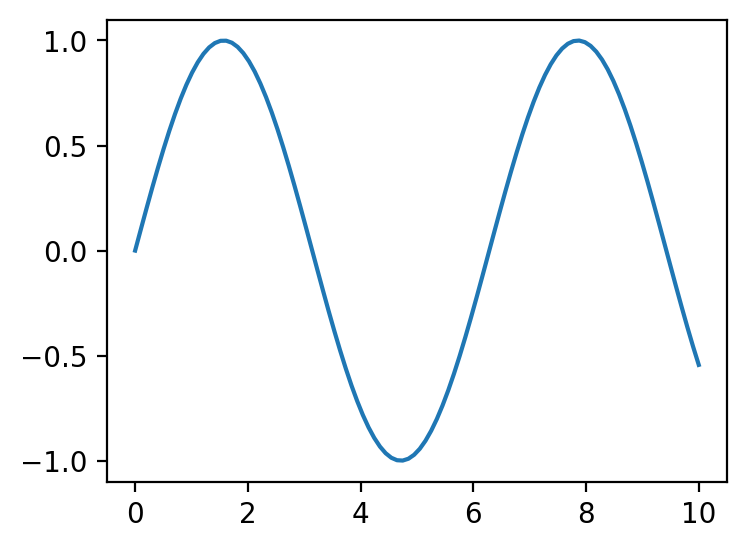

In [22]:
import os
output_dir = '../../_build/generated'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'filename.png')


x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y)

if not os.path.isfile(output_file):         # check file
    fig.savefig(output_file)
    # fig.savefig("../../figures/filename.png")  ### same as above, we can use the variable output_file to specify the path
    print(f"Saved: {output_file}")
else:
    print(f"File already exists: {output_file}")